# Study 7: Most Improved Countries by CO₂ per Capita 

Which countries have reduced their per capita CO₂ emissions the most over time?

### Objective:

To Identify Most Improved Countries by CO₂ per Capita, we compare the lastest CO₂ emissions between 2020 and 2005

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from modules.data_loader import DataLoader

## Load Preprocessed Data
We load 4 databases and merge into a single DataFrame with the following columns:
 `Continent`, `Country`, `year`, `co2`, `gdp`, `population`, `total_co2`, `total_gdp`

In [6]:
# Load the preprocessed CSV 
loader = DataLoader()            # Create an instance of the DataLoader class
data = loader.load_and_prepare_data()  # Call the method to load and clean the data
data.head(10)

,Continent,Country,year,co2,gdp,population,total_gdp,total_co2
0,Africa,Algeria,1800,0.0,763.0,2500000.0,1.907500e+09,0.0
1,Africa,Algeria,1801,0.0,764.0,2510000.0,1.917640e+09,0.0
2,Africa,Algeria,1802,0.0,765.0,2520000.0,1.927800e+09,0.0
3,Africa,Algeria,1803,0.0,766.0,2530000.0,1.937980e+09,0.0
4,Africa,Algeria,1804,0.0,767.0,2540000.0,1.948180e+09,0.0
5,Africa,Algeria,1805,0.0,768.0,2550000.0,1.958400e+09,0.0
6,Africa,Algeria,1806,0.0,769.0,2560000.0,1.968640e+09,0.0
7,Africa,Algeria,1807,0.0,770.0,2560000.0,1.971200e+09,0.0
8,Africa,Algeria,1808,0.0,771.0,2570000.0,1.981470e+09,0.0
9,Africa,Algeria,1809,0.0,772.0,2580000.0,1.991760e+09,0.0


## Plot: CO₂ reduction since 2005
Visualizing the CO₂ emissions reduction since the year 2005.

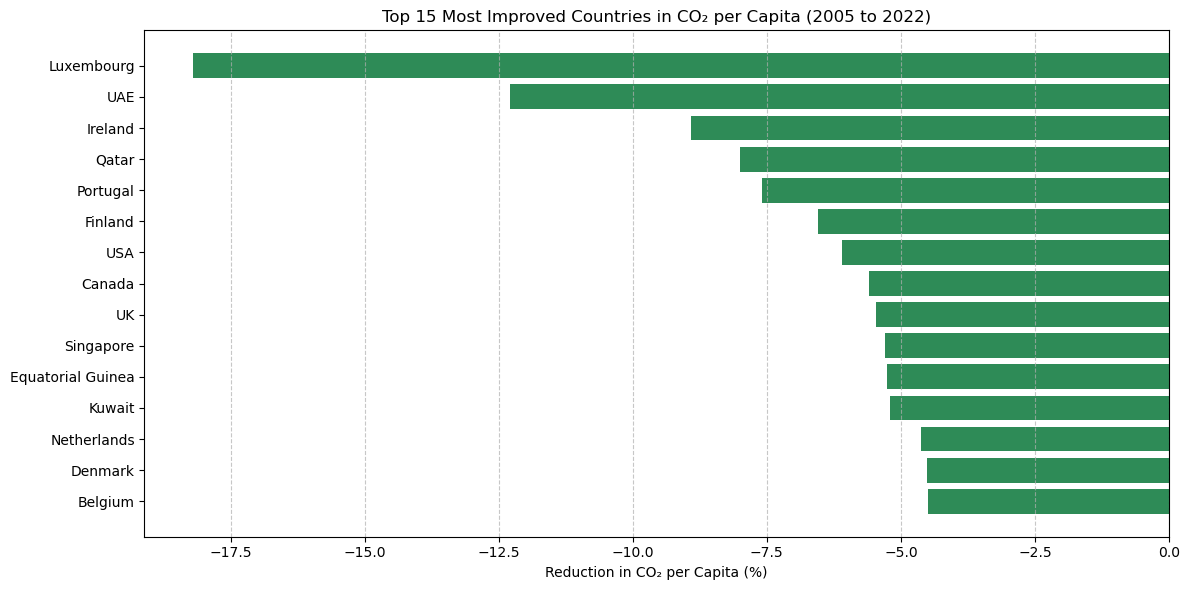

In [30]:
# Define years
start_year = 2005
end_year = 2022

# Ensure country names are consistent
data["Country"] = data["Country"].str.strip()

# Filter data for the start and end years
start_data = data[data["year"] == start_year][["Country", "co2"]].copy()
end_data = data[data["year"] == end_year][["Country", "co2"]].copy()

# Rename columns for clarity
start_data.rename(columns={"co2": "start_co2"}, inplace=True)
end_data.rename(columns={"co2": "end_co2"}, inplace=True)

# Merge data on Country
change_df = pd.merge(start_data, end_data, on="Country", how="inner")

# Drop missing values
change_df.dropna(inplace=True)

# Calculate absolute and percent change
change_df["change"] = change_df["end_co2"] - change_df["start_co2"]
change_df["percent_change"] = 100 * (change_df["change"] / change_df["start_co2"].replace(0, float("nan")))

# Filter out countries with very small initial emissions to avoid distortion
change_df = change_df[change_df["start_co2"] > 1.0]

# Get top 15 countries with the largest decrease in CO2 per capita
most_improved = change_df.sort_values(by="change").head(15)

# Plot the results
plt.figure(figsize=(12, 6))
bars = plt.barh(most_improved["Country"], most_improved["change"], color="seagreen")
plt.xlabel("Reduction in CO₂ per Capita (%)")
plt.title(f"Top 15 Most Improved Countries in CO₂ per Capita ({start_year} to {end_year})")
plt.gca().invert_yaxis()  # Show largest improvements at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Leading Improvers:

**Luxembourg** stands out as the top performer by a significant margin, achieving a reduction of over 17.5 % of CO2 per capita. This is a remarkably high reduction compared to other countries on the list.

**United Arab Emirates (UAE) and Ireland** follow, with substantial reductions of approximately 12.5% and 10.5% respectively.







## Plot: CO₂ reduction since Paris Agreement (signed in 2015)

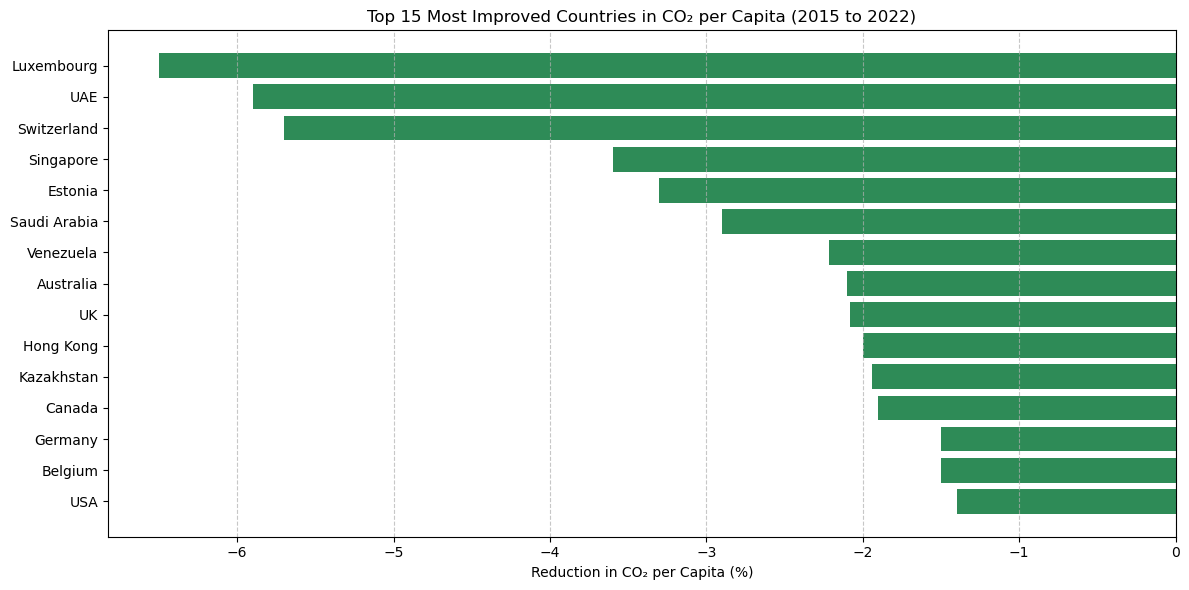

In [31]:
# Define years
start_year = 2015
end_year = 2022

# Ensure country names are consistent
data["Country"] = data["Country"].str.strip()

# Filter data for the start and end years
start_data = data[data["year"] == start_year][["Country", "co2"]].copy()
end_data = data[data["year"] == end_year][["Country", "co2"]].copy()

# Rename columns for clarity
start_data.rename(columns={"co2": "start_co2"}, inplace=True)
end_data.rename(columns={"co2": "end_co2"}, inplace=True)

# Merge data on Country
change_df = pd.merge(start_data, end_data, on="Country", how="inner")

# Drop missing values
change_df.dropna(inplace=True)

# Calculate absolute and percent change
change_df["change"] = change_df["end_co2"] - change_df["start_co2"]
change_df["percent_change"] = 100 * (change_df["change"] / change_df["start_co2"].replace(0, float("nan")))

# Filter out countries with very small initial emissions to avoid distortion
change_df = change_df[change_df["start_co2"] > 1.0]

# Get top 15 countries with the largest decrease in CO2 per capita
most_improved = change_df.sort_values(by="change").head(15)

# Plot the results
plt.figure(figsize=(12, 6))
bars = plt.barh(most_improved["Country"], most_improved["change"], color="seagreen")
plt.xlabel("Reduction in CO₂ per Capita (%)")
plt.title(f"Top 15 Most Improved Countries in CO₂ per Capita ({start_year} to {end_year})")
plt.gca().invert_yaxis()  # Show largest improvements at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Key Observations
 
There's significant overlap in the countries appearing on both plots (e.g., Luxembourg, UAE, Singapore, Canada, Germany, UK, Belgium, USA). This suggests that many countries are consistently working to reduce their per capita emissions

**Developed Nations:** Luxembourg, Switzerland, Singapore, Estonia, Australia, UK, Hong Kong, Canada, Germany, Belgium, USA are all highly developed economies.

**Oil/Gas Producers:** UAE, Saudi Arabia, Venezuela, and Kazakhstan appear on this list, suggesting these countries are also making percentage-based improvements in their per capita emissions during this more recent period.